In [566]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

### Завдання 1. 

[10 балів]

Для датасету `<прізвище>_shopping-data.csv`
(Чотири ознаки : sex, age, annual income, spending score)  


1. Побудувати ієрархічну кластеризацію (дендрограму). 
2. За допомогою `AgglomerativeClustering` з `sklearn.cluster` отримати кластеризацію на 5 кластерів.
3. Візуалізувати 5 кластерів на площині (перебираючи попарно ознаки). 
4. Підбором параметрів `affinity` та `linkage` досягти найкращої плоскої візуалізації 5 кластерів для ознак `Age` та `Annual Income`.

<font color='CornflowerBlue' size=3>Зчитаємо датасет і переведемо колонку `Sex` в бінарну для можливості шукати евклідову відстань</font>

In [2]:
data = pd.read_csv("Мазуренко_shopping-data.csv")
data["Sex"] = data["Sex"].map(lambda x: 1 if x == "Male" else 0)

In [3]:
data

,Sex,Age,Annual Income (k$),Spending Score (1-100)
0,1,21,15,81
1,0,34,58,60
2,1,19,74,10
3,0,22,17,76
4,1,57,54,51
...,...,...,...,...
145,0,22,57,55
146,1,32,75,93
147,0,66,63,50
148,0,57,75,5


### 1. Побудуємо дендрограму ієрархічної кластирезації

<font color='CornflowerBlue' size=3>Функція, що будує діаграму</font>

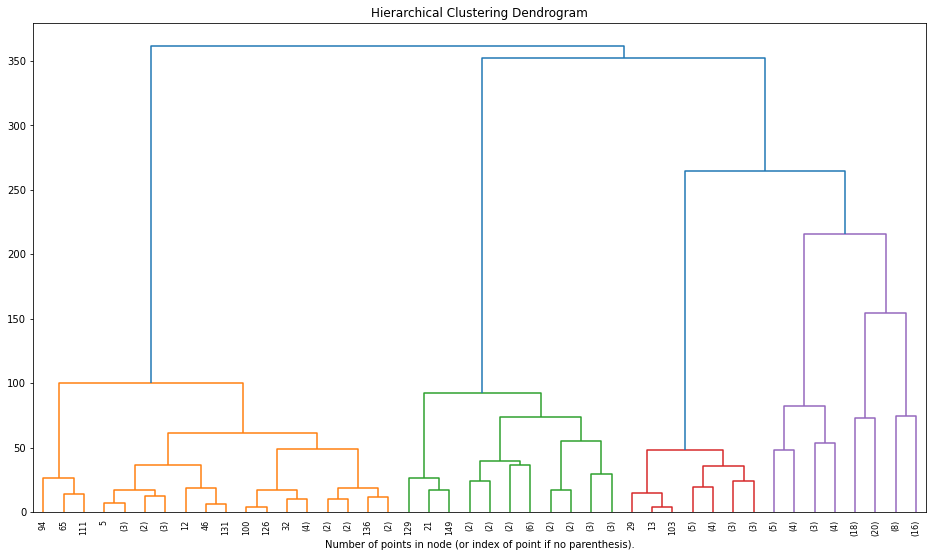

In [4]:
from sklearn.cluster import AgglomerativeClustering
def plot_dendrogram(model, **kwargs):

    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)
    return linkage_matrix

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(data)
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_title("Hierarchical Clustering Dendrogram")
lm = plot_dendrogram(model, truncate_mode="level", p=5)
ax.set_xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

<font color='CornflowerBlue' size=3>Також можемо подивитись на саму `linkage_matrix`, з якої будується дендрограма</font>

In [5]:
print(lm)

[[ 73.         138.           1.           2.        ]
 [  3.          74.           1.73205081   2.        ]
 [ 41.         140.           2.           2.        ]
 [ 87.         147.           2.23606798   2.        ]
 [  8.          49.           2.23606798   2.        ]
 [ 17.          64.           2.44948974   2.        ]
 [ 25.          62.           2.64575131   2.        ]
 [ 36.         141.           2.64575131   2.        ]
 [ 59.         155.           2.94392029   3.        ]
 [ 53.          93.           3.           2.        ]
 [ 70.          77.           3.           2.        ]
 [ 43.         142.           3.           2.        ]
 [  9.         110.           3.16227766   2.        ]
 [106.         125.           3.16227766   2.        ]
 [ 66.          91.           3.60555128   2.        ]
 [ 50.         153.           3.6968455    3.        ]
 [ 27.         124.           3.74165739   2.        ]
 [ 13.         103.           4.12310563   2.        ]
 [ 99.    

<font color='CornflowerBlue' size=3>І переконатись, що відстані, пораховані за допомогою `AgglomerativeClustering` справді відповідні</font>

In [6]:
from scipy.spatial.distance import euclidean
def get_point_distance(id1, id2, data):
    print("-"* 20 + f" Object {id1} " + "-"*20)
    print(data.iloc[id1])
    print("-"* 20 + f" Object {id2} " + "-"*20)
    print(data.iloc[id2])
    print("-"* 20 + " Distance " + "-"*20)
    print(euclidean(data.iloc[id1], data.iloc[id2]))
get_point_distance(17, 64, data)

-------------------- Object 17 --------------------
Sex                        1
Age                       48
Annual Income (k$)        60
Spending Score (1-100)    49
Name: 17, dtype: int64
-------------------- Object 64 --------------------
Sex                        0
Age                       47
Annual Income (k$)        60
Spending Score (1-100)    47
Name: 64, dtype: int64
-------------------- Distance --------------------
2.449489742783178


### 2. Отримаємо кластеризацію на 5 кластерів

<font color='CornflowerBlue' size=3>Використовуємо стандартні параметри з `afinity = euclidean` i `linkage = ward`</font>

In [7]:
agg_cl = AgglomerativeClustering(n_clusters=5).fit(data)
agg_cl.labels_

array([3, 0, 2, 3, 0, 1, 0, 0, 0, 4, 1, 2, 1, 3, 0, 4, 3, 0, 0, 0, 4, 2,
       2, 4, 0, 1, 3, 1, 0, 3, 0, 0, 1, 4, 4, 0, 0, 1, 2, 4, 3, 0, 0, 2,
       1, 1, 1, 3, 1, 0, 0, 2, 2, 3, 0, 0, 4, 0, 0, 0, 2, 0, 1, 3, 0, 1,
       0, 0, 2, 1, 0, 0, 0, 0, 3, 0, 2, 0, 2, 2, 0, 0, 1, 2, 0, 3, 0, 0,
       0, 4, 0, 0, 4, 3, 1, 1, 1, 0, 2, 0, 1, 4, 1, 3, 2, 1, 0, 1, 0, 0,
       4, 1, 1, 0, 0, 2, 4, 0, 3, 0, 2, 3, 3, 4, 1, 0, 1, 0, 2, 2, 0, 1,
       3, 4, 0, 4, 1, 2, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 2], dtype=int64)

<font color='CornflowerBlue' size=3>Візуалізуємо розподіл кластерів</font>

<AxesSubplot:xlabel='Cluster', ylabel='count'>

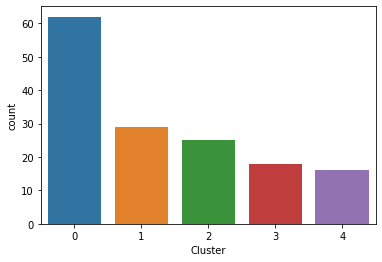

In [8]:
clusters = data.copy()
clusters["Cluster"] = agg_cl.labels_
sns.countplot(data=clusters, x = "Cluster")

### 3. Візуалізуємо кластери на площинах по всеможливих парах координат

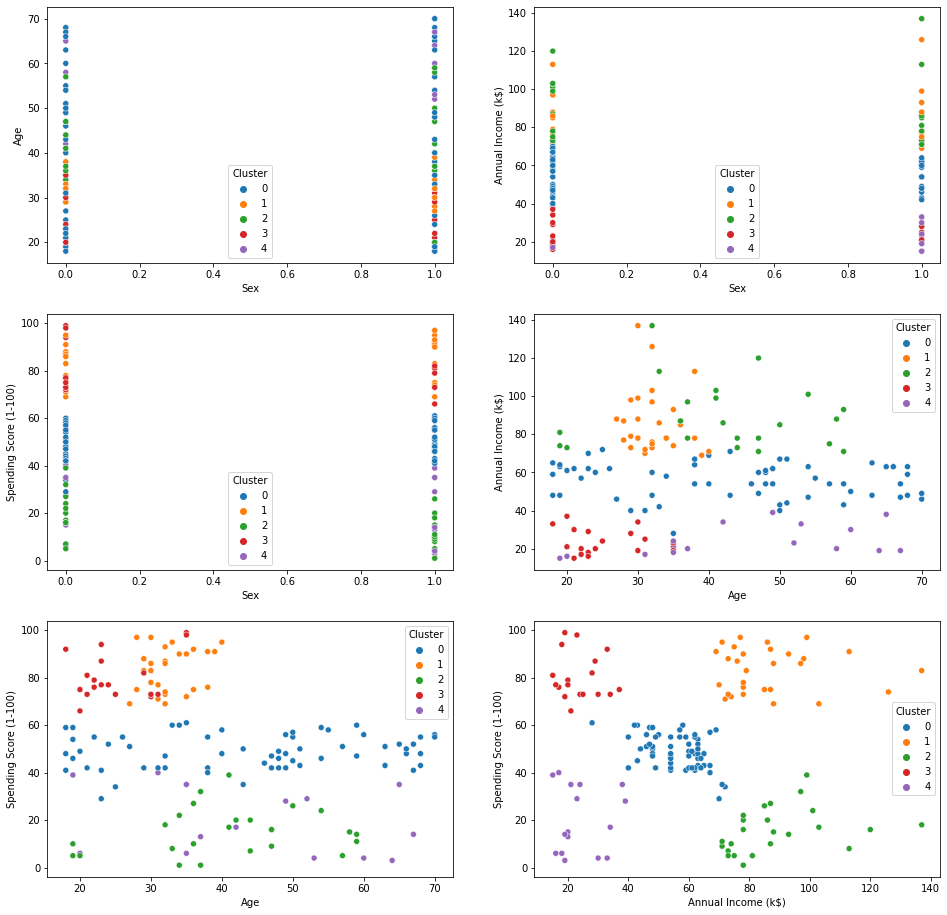

In [9]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(16, 16))
ax_c = 0
for i in range(4):
    for j in range(4):
        if i < j:
            sns.scatterplot(data=clusters, x = clusters.columns[i], y = clusters.columns[j], hue="Cluster", palette = "tab10", ax = ax[ax_c // 2, ax_c % 2])
            ax_c += 1


Бачимо, що найкращий поділ для ознак `Spending Score` і `Annual income`, що не  дивно, адже ми використовуємо параметр `linkage = ward` i евклідову відстань, а ці параметри мають найбільший розмах, тобто найбільше впливають на поділ кластерів

### 4. Підберемо параметри для найкращої візуалізації по `Age` i `Annual income`

<font color='CornflowerBlue' size=3>Спробуємо кластеризацію з іншими параметрами `linkage`. Судити успішність кластеризації будемо по графіку і використовуючи `Коефіцієнт силуета`</font>

In [10]:
from sklearn.metrics import silhouette_score
def get_clusters(model, columns=data.columns):
    global data
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    model.fit(data[columns])
    clusters = data.copy()
    clusters["Cluster"] = model.labels_
    metric = model.get_params()["metric"] if model.get_params()["metric"] != None else "euclidean"
    print("-"*20 + f" {model.get_params()['linkage'].capitalize()} " + "-"*20)
    print(f"Total silhouette score: {silhouette_score(data, model.labels_, metric=metric)}")
    #sns.scatterplot(data=clusters, y = "Spending Score (1-100)", x = "Annual Income (k$)", hue="Cluster", palette = "tab10", ax = ax[0])
    sns.countplot(data=clusters, x = "Cluster", ax = ax[0])
    print(f"Age-Income silhouette score: {silhouette_score(data.loc[:,['Age', 'Annual Income (k$)']], model.labels_, metric=metric)}")
    sns.scatterplot(data=clusters, x = "Age", y = "Annual Income (k$)", hue="Cluster", palette = "tab10", ax = ax[1])
    

-------------------- Ward --------------------
Total silhouette score: 0.4613837892660293
Age-Income silhouette score: 0.1569087382147438
-------------------- Complete --------------------
Total silhouette score: 0.37480738467366514
Age-Income silhouette score: 0.12306082959727457
-------------------- Average --------------------
Total silhouette score: 0.4613837892660293
Age-Income silhouette score: 0.1569087382147438
-------------------- Single --------------------
Total silhouette score: -0.05200874186945032
Age-Income silhouette score: 0.019285572638443854


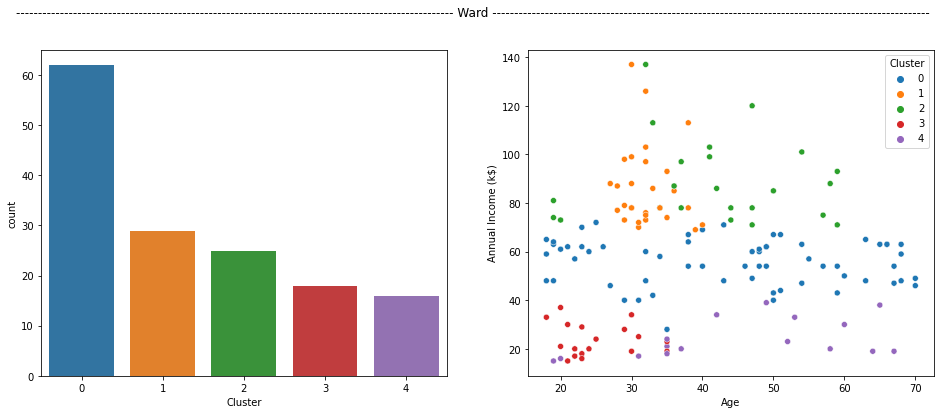

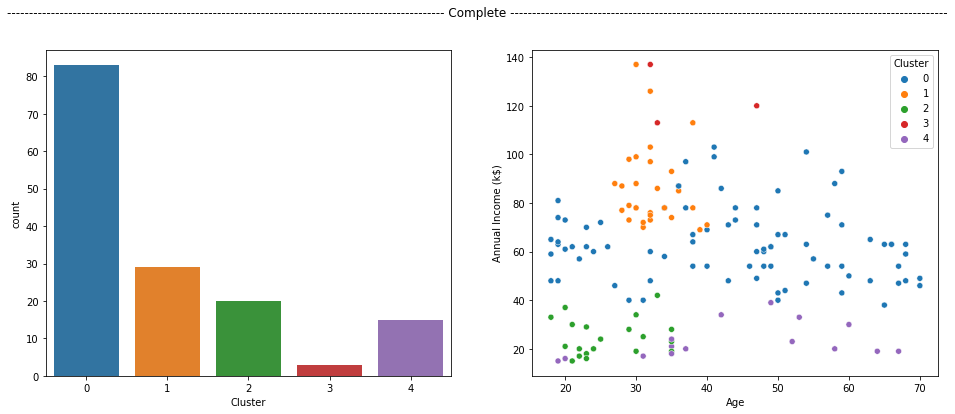

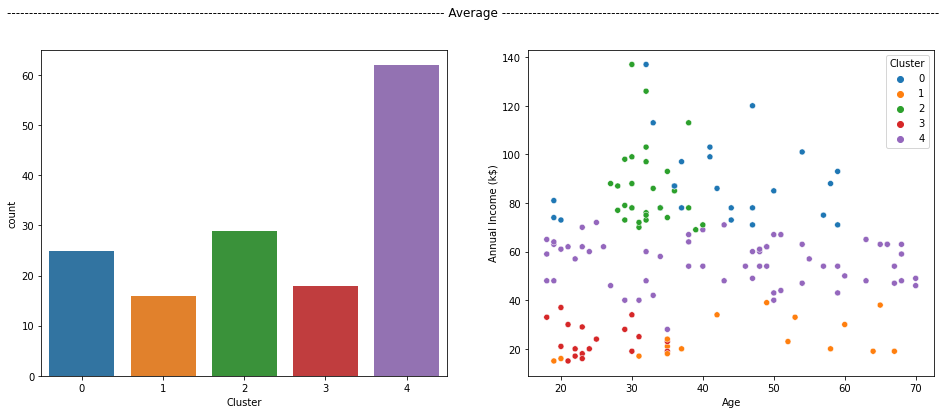

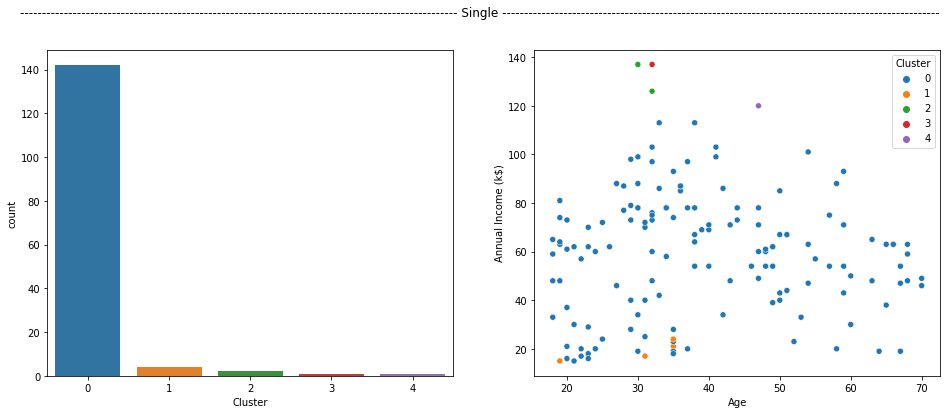

In [11]:
for linkage in ["ward", "complete", "average", "single"]:
    get_clusters(AgglomerativeClustering(n_clusters=5, linkage=linkage))
    plt.suptitle("-"*100 + f" {linkage.capitalize()} " + "-" * 100)

Бачимо, що як візуально, так і за оцінкою якості кластеризація не покращується

<font color='CornflowerBlue' size=3>Спробуємо тепер підібрати параметри для кластеризації за допомогою `GriedSearchCV`</font>

In [12]:
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X.loc[:,['Age', 'Annual Income (k$)']], labels)

In [13]:
from sklearn.model_selection import GridSearchCV
param_grid = {
            "linkage": ["complete", "average", "single"],
            "metric": ["euclidean", "manhattan", "cosine"],
        }
searcher = GridSearchCV(AgglomerativeClustering(n_clusters=5), [param_grid],
                scoring=silhouette_scorer, cv=5, n_jobs=-1)
searcher.fit(data)
searcher.best_params_.items()

dict_items([('linkage', 'average'), ('metric', 'manhattan')])

-------------------- Average --------------------
Total silhouette score: 0.4860381638696259
Age-Income silhouette score: 0.17136676187727398


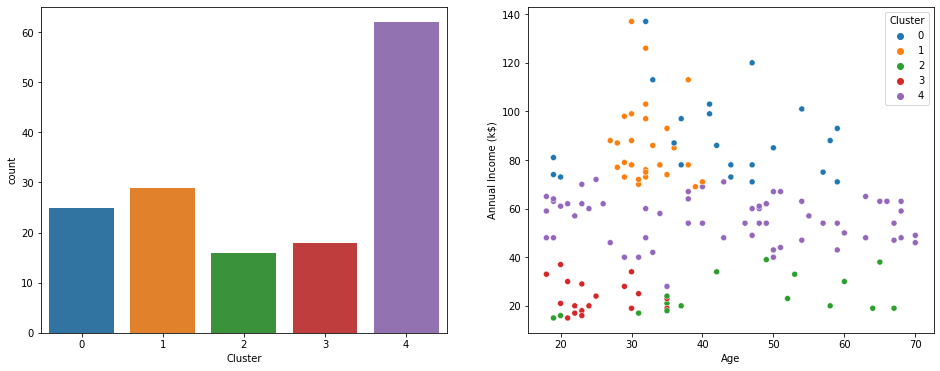

In [14]:
get_clusters(AgglomerativeClustering(n_clusters=5, linkage="average", metric="manhattan"))

Бачимо, що хоч і `silhouette score` незначно покращився, але це пов'язано з його розрахунком через іншу метрику, а не з зміною кластерів

<font color='CornflowerBlue' size=3>Можливо результати покращаться, якщо провести кластеризацію тільки за цими двома ознаками</font>

-------------------- Ward --------------------
Total silhouette score: 0.23252583694610593
Age-Income silhouette score: 0.37588240441828197


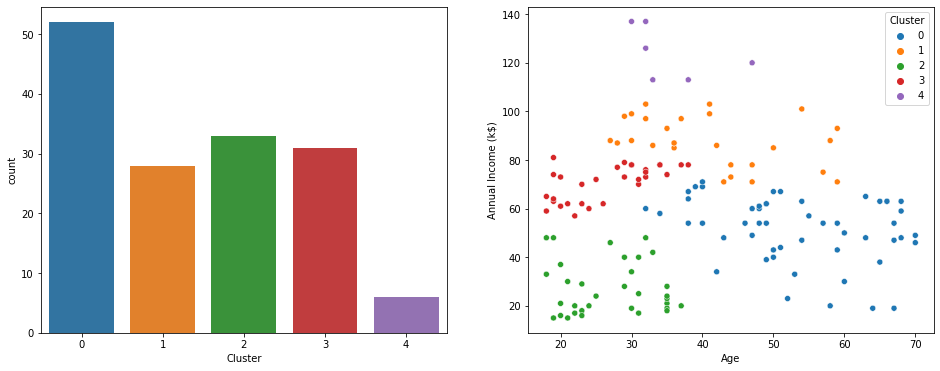

In [15]:
get_clusters(AgglomerativeClustering(n_clusters=5), columns=["Age", "Annual Income (k$)"])

І додатково підібравши параметри

In [16]:
param_grid = {
            "linkage": ["complete", "average", "single"],
            "metric": ["euclidean", "manhattan", "cosine"],
        }
searcher = GridSearchCV(AgglomerativeClustering(n_clusters=5), [param_grid],
                scoring=silhouette_scorer, cv=5, n_jobs=-1)
searcher.fit(data[["Age", "Annual Income (k$)"]])
searcher.best_params_.items()

dict_items([('linkage', 'average'), ('metric', 'euclidean')])

-------------------- Average --------------------
Total silhouette score: 0.24515204569817597
Age-Income silhouette score: 0.42382031926603553


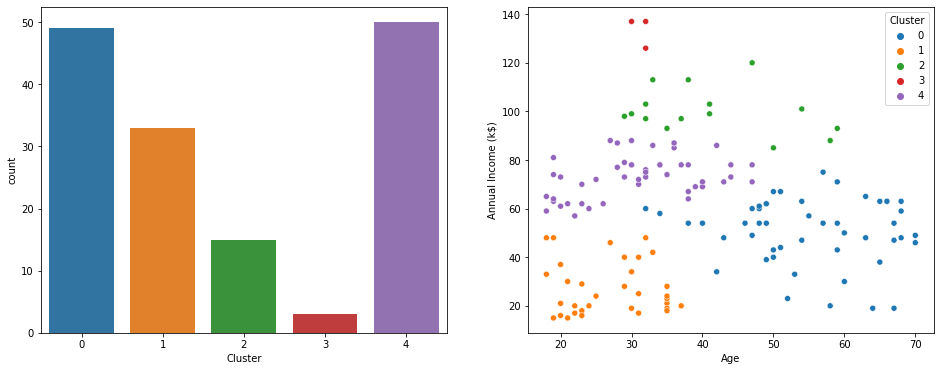

In [17]:
get_clusters(AgglomerativeClustering(n_clusters=5, linkage="average"), columns=["Age", "Annual Income (k$)"])

Результат, очевидно, значно покращився

### Завдання 2. 

[12 балів] + [прогнози: до 6 балів]

Для датасету `data300_train.csv`
(300 числових ознак, цільова змінна "Category" приймає два значення)

1. За допомогою бегінгу над деревами отримати якомога кращий класифікатор (провести пошук оптимальних параметрів -- глибина дерев, кількість дерев, кількість ознак і т.д.)

2. За допомогою градієнтного бустингу над деревами отримати якомога кращий класифікатор (провести пошук оптимальних параметрів -- темп навчання, глибина дерев, кількість дерев, кількість ознак і т.д.)

3. Зберегти прогнози найкращої моделі на датасеті `data300_test.csv` до файлу `predictions_ens.csv`

4. Вилучивши `"Category"` спробувати отримати кластеризацію на два кластери, що відповідають значенням `"Category"` використовуючи алгоритми K-means та DBSCAN


### Data Analysis

In [539]:
data_train = pd.read_csv("data300_train.csv")
data_train

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_292,x_293,x_294,x_295,x_296,x_297,x_298,x_299,x_300,Category
0,-0.85,0.12,-0.08,1.17,-0.79,0.56,0.11,-0.06,-0.10,-2.01,...,0.38,-0.02,1.31,-0.04,2.35,-0.02,1.20,0.18,-0.00,-1.0
1,-0.13,0.22,-0.00,-0.07,0.17,0.78,1.12,0.39,-0.00,-1.17,...,0.36,-0.03,1.55,-0.00,-2.96,-0.03,0.98,1.36,-0.02,-1.0
2,-0.17,0.58,0.01,-0.62,1.13,-0.63,-0.59,0.11,0.02,-0.93,...,0.77,0.00,-0.68,0.00,-0.28,0.00,-0.05,0.72,0.01,1.0
3,0.10,0.84,0.04,-1.20,-0.52,1.97,-0.65,-0.33,0.06,0.22,...,0.52,0.00,0.35,0.00,-0.69,0.14,-0.18,-0.99,0.04,1.0
4,-0.87,0.30,0.02,-1.15,0.08,0.62,-0.03,0.87,0.04,0.29,...,1.49,0.02,0.24,0.00,0.69,0.00,-1.02,-1.01,0.00,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-0.97,-0.56,-0.00,-0.44,-0.77,-0.31,1.69,-1.66,-0.00,-1.80,...,0.43,-0.03,-0.01,-0.01,1.12,-0.04,0.38,-0.24,-0.03,-1.0
39996,0.53,0.09,0.01,-0.65,0.90,-0.32,0.12,2.19,0.00,-0.30,...,-1.86,0.02,-0.22,0.02,-0.30,0.02,-1.13,-0.88,0.04,1.0
39997,1.70,0.05,0.00,2.03,-1.16,-0.77,0.32,-0.00,0.12,-2.68,...,0.86,0.02,0.05,0.02,-0.35,0.00,-0.09,-0.10,0.04,1.0
39998,0.99,0.34,0.08,0.25,1.05,-1.70,-0.48,-1.86,0.02,-0.49,...,0.39,0.06,1.00,0.02,-1.16,0.06,0.86,-1.14,0.08,1.0


In [540]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 301 entries, x_1 to Category
dtypes: float64(301)
memory usage: 91.9 MB


In [541]:
data_train.isnull().values.any()

False

Отже маємо 40 000 non-null значень, 300 ознак і цільову змінну

Подивимось на поділ класів

-1.0    20134
 1.0    19866
Name: Category, dtype: int64

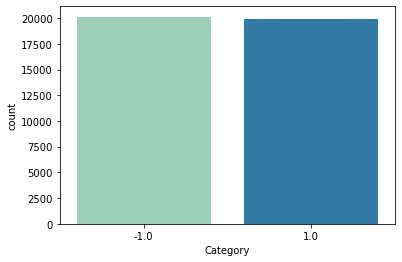

In [542]:
sns.countplot(x='Category',data=data_train, palette="YlGnBu")
data_train["Category"].value_counts()

Знайдемо мінімальну і максимальну кореляцію між ознаками, оскільки 300 ознак не підходять для зручної візуалізації

In [543]:
corr = data_train.drop(columns=["Category"]).corr()
print(f"Min correlation: {corr.min().min()}")
print(f"Max correlation: {corr[corr<1].max().max()}")

Min correlation: -0.02146426355400524
Max correlation: 0.4799679982559552


Спробуємо визначити об'єкти з аномальними значеннями числових ознак і видалити їх. Робити це будемо наступним чином:
* Напишемо функцію, яка в циклі буде проходити по кожній числовій ознаці і визначати викиди
* На кожній ітерації викидом вважатимемо те значення, яке `менше за 1-ий квантиль - крок викиду` або `більше за 3-ій квантиль + крок викиду`
* За крок викиду візьмемо 1,5 * IQR (Interquartile range)
* Для кожної ознаки записуватимемо індекси викидів в список. Після обробки всіх ознак видалятимемо ті рядки, поява яких в списку викидів перевищувала n разів

In [23]:
from collections import Counter
def outliers(df, features, n):
    outliers_ids = []
    for feature in features:
        q1 = np.percentile(df[feature], 25)
        q3 = np.percentile(df[feature], 75)
        step = 1.5*(q3 - q1)
        ids = df[(df[feature] < q1 - step) | (df[feature] > q3 + step)].index
        outliers_ids.extend(ids)
    outliers_ids = Counter(outliers_ids)
    delete = [key for key,value in outliers_ids.items() if value > n]
    return delete
delete = outliers(data_train, data_train.columns[:-1], 20)
len(delete)

9342

### Feature Selection

<font color='CornflowerBlue' size=3>Вибирати ознаки для навчання будемо наступним чином:</font>
1. Всі ознаки: `features`
2. Ознаки з кореляцією `< 0.3`: `low_corr`
3. Ознаки, вибрані за допомогою `SeguentialFeatureSelector`: `lin_selected`
4. Ознаки, вибрані за допомогою `RandomForest`: `tree_selected`
5. Ознаки, з ненульовими коефіцієнтами з `l1` регуляризацією: `l1_selected`
6. Ознаки, вибрані функцією оцінки `chi2`: `chi_selected`
7. Перетин всіх пунктів вище

In [24]:
X = data_train.drop(columns=["Category"])
y = data_train["Category"]

### 1.

In [15]:
features = X.columns
features

Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_291', 'x_292', 'x_293', 'x_294', 'x_295', 'x_296', 'x_297', 'x_298',
       'x_299', 'x_300'],
      dtype='object', length=300)

### 2.

In [26]:
a = corr.copy()
corr.apply(lambda col: a.drop(columns=[col.name], inplace=True) if col[(col<1) & (col>0.3)].count() != 0 else None, axis = 1)
a[(a > 0.35) & (a < 1)].any().any()

False

In [27]:
low_corr = a.columns
low_corr

Index(['x_1', 'x_2', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_10', 'x_11', 'x_12',
       ...
       'x_287', 'x_288', 'x_289', 'x_290', 'x_291', 'x_292', 'x_294', 'x_296',
       'x_298', 'x_299'],
      dtype='object', length=241)

### 3.

In [28]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

sfs = SequentialFeatureSelector(LogisticRegression(), n_jobs = -1, n_features_to_select = 50, cv = 3)
scaler=StandardScaler()
scaled = scaler.fit_transform(X)
sfs.fit(scaled, y)
lin_selected = features[sfs.get_support()]
lin_selected

Index(['x_5', 'x_11', 'x_13', 'x_25', 'x_26', 'x_34', 'x_36', 'x_37', 'x_39',
       'x_40', 'x_43', 'x_45', 'x_52', 'x_65', 'x_69', 'x_88', 'x_96', 'x_98',
       'x_101', 'x_107', 'x_115', 'x_118', 'x_127', 'x_132', 'x_135', 'x_136',
       'x_146', 'x_150', 'x_153', 'x_154', 'x_167', 'x_175', 'x_177', 'x_179',
       'x_184', 'x_196', 'x_206', 'x_209', 'x_218', 'x_222', 'x_232', 'x_249',
       'x_251', 'x_252', 'x_265', 'x_267', 'x_269', 'x_276', 'x_293', 'x_300'],
      dtype='object')

### 4.

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth = 5, random_state = 4)
scaled = scaler.fit_transform(X)
model.fit(scaled, y)
feature_importances = model.feature_importances_
indices = (-feature_importances).argsort()[:50]
X_new = X.iloc[:, indices]
tree_selected = X_new.columns
tree_selected

Index(['x_300', 'x_269', 'x_218', 'x_48', 'x_23', 'x_293', 'x_226', 'x_224',
       'x_87', 'x_82', 'x_9', 'x_51', 'x_178', 'x_73', 'x_159', 'x_297',
       'x_117', 'x_30', 'x_113', 'x_235', 'x_137', 'x_173', 'x_33', 'x_275',
       'x_243', 'x_276', 'x_147', 'x_217', 'x_3', 'x_156', 'x_50', 'x_19',
       'x_281', 'x_236', 'x_104', 'x_54', 'x_14', 'x_21', 'x_47', 'x_145',
       'x_24', 'x_81', 'x_233', 'x_223', 'x_134', 'x_100', 'x_76', 'x_116',
       'x_90', 'x_70'],
      dtype='object')

### 5.

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l1', solver='liblinear')
scaled = scaler.fit_transform(X)
model.fit(scaled, y)
indices = np.where(model.coef_[0] != 0)[0]
X_new = X.iloc[:, indices]
l1_selected = X_new.columns
l1_selected

Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_291', 'x_292', 'x_293', 'x_294', 'x_295', 'x_296', 'x_297', 'x_298',
       'x_299', 'x_300'],
      dtype='object', length=299)

### 6.

In [31]:
from sklearn.feature_selection import SelectKBest, f_classif

model = SelectKBest(f_classif, k=50)
model.fit(scaled, y)
indices = model.scores_.argsort()[-50:]
X_new = X.iloc[:, indices]
f_selected = X_new.columns
f_selected

Index(['x_100', 'x_81', 'x_40', 'x_90', 'x_50', 'x_295', 'x_145', 'x_70',
       'x_134', 'x_275', 'x_47', 'x_147', 'x_248', 'x_54', 'x_14', 'x_156',
       'x_217', 'x_116', 'x_21', 'x_233', 'x_19', 'x_24', 'x_33', 'x_235',
       'x_3', 'x_276', 'x_243', 'x_281', 'x_178', 'x_297', 'x_236', 'x_117',
       'x_30', 'x_51', 'x_173', 'x_137', 'x_159', 'x_113', 'x_9', 'x_82',
       'x_73', 'x_226', 'x_293', 'x_218', 'x_269', 'x_48', 'x_224', 'x_87',
       'x_23', 'x_300'],
      dtype='object')

### 7.

In [32]:
combined = np.intersect1d(f_selected,tree_selected)
combined = np.intersect1d(combined,lin_selected)
combined

array(['x_218', 'x_269', 'x_276', 'x_293', 'x_300'], dtype=object)

### Classification

Поділимо дані на навчальні і тестові

In [545]:
from sklearn.model_selection import train_test_split
def get_original():
    global X, y, X_train, X_test, y_train, y_test
    X = data_train.drop(columns=["Category"])
    y = data_train["Category"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=4)
get_original()

<font color='CornflowerBlue' size=3>Необхідні для навчання функції</font>

In [544]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate
def get_best_params(pipeline):
    global X_train, X_test, y_train, y_test  
    if  type(pipeline[1]) == sklearn.tree._classes.DecisionTreeClassifier:
        param_grid = {
            "regression__criterion": ["gini", "entropy", "log_loss"],
            "regression__max_depth" : [None,2, 3,5,7,9,11,12],
            "regression__min_samples_leaf":[1, 2, 3, 5, 10, 20, 30, 40, 50],
            "regression__max_features":[50, "sqrt", "log2", None]           
        }
        searcher = RandomizedSearchCV(pipeline, [param_grid],
                        scoring="accuracy",cv=3, n_iter=300, n_jobs=-1, random_state=53)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)

             
def output(pipeline, best_base_params=True, best_params=False, cv=True, all_metrics=False):
    global X_train, X_test, y_train, y_test
    if best_base_params:
        models = [pipeline[1].estimator]
        for model in models:
            inner_pipeline = Pipeline(steps=[
                ('preprocessing', pipeline[0]),
                ('regression', model)
            ])
            get_best_params(inner_pipeline)
    if best_params:
        if type(pipeline[1]) == sklearn.ensemble._bagging.BaggingClassifier:
            param_grid = {
                "regression__n_estimators": range(2, 30, 2),
                "regression__max_samples": np.arange(0.2, 1.01, 0.2),
                "regression__bootstrap": [True,False],
                "regression__max_features": np.arange(0.2, 1.01, 0.2),
                "regression__bootstrap_features": [True,False]
            }
            searcher = RandomizedSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=3, n_jobs=-1, n_iter = 50, random_state = 4)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._gb.GradientBoostingClassifier:
            param_grid = {
            "regression__loss": ["log_loss", "exponential"],
            "regression__learning_rate": np.logspace(-3, 2, 25),
            "regression__n_estimators": range(10, 301, 10),
            "regression__criterion": ["squared_error", "friedman_mse"],        
            "regression__max_depth" : [None,3,5,7,9,11,12],
            "regression__min_samples_leaf":[1, 2, 3, 4, 5, 10, 20, 30],
            "regression__max_features":["sqrt", "log2", None],
            "regression__subsample":np.arange(0.2, 1.01, 0.2)
            }
            searcher = RandomizedSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=3, n_jobs=-1, random_state=4, n_iter=25)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        
    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_train)
    y_pred = pipeline.predict(X_test)
    print("-"*10 + f"{pipeline[1]}" + "-"*10)
    print(f"Test Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
    print(f"Train Accuracy: {round(accuracy_score(y_train, y_train_pred), 4)}")
    if cv:
        eval_cv([pipeline], False)
    if all_metrics:
        for metric, scorer in {"Precision":precision_score,"Recall":recall_score,"F1":f1_score, "ROC_AUC":roc_auc_score}.items():
            print()
            print(f"Test {metric}: {round(scorer(y_test, y_pred), 4)}")
            print(f"Train {metric}: {round(scorer(y_train, y_train_pred), 4)}")
            
            
def eval_cv(pipelines, title=True):
    global X_train, y_train
    for pipeline in pipelines:
        bagging_cv = cross_validate(pipeline, X_train, y_train, n_jobs=-1,
                    cv=RepeatedKFold(n_splits=3, n_repeats=3), scoring="accuracy")
        if title:
            print(f"{pipeline} -----> {round(bagging_cv['test_score'].mean(),4)}")
        else:
            print(f"CV mean Result: {round(bagging_cv['test_score'].mean(),4)}")        

        
    

### Bagging Classifier

<font color='CornflowerBlue' size=3>Спробуємо спочатку чисту модель</font>

In [35]:
from sklearn.ensemble import BaggingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', BaggingClassifier(DecisionTreeClassifier(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline, best_base_params=False)

----------BaggingClassifier(estimator=DecisionTreeClassifier(random_state=4), n_jobs=-1,
                  random_state=5)----------
Test Accuracy: 0.7916
Train Accuracy: 0.9927
CV mean Result: 0.7832


Бачимо, що присутнє значне перенавчання (через непідібрану глибину дерев). Підберемо найкращі параметри для дерев і додамо скейлинг.

In [36]:
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', BaggingClassifier(DecisionTreeClassifier(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline)

----------BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                   max_depth=7,
                                                   min_samples_leaf=5,
                                                   random_state=4),
                  n_jobs=-1, random_state=5)----------
Test Accuracy: 0.7629
Train Accuracy: 0.7759
CV mean Result: 0.7656


Результати незначно погіршились, що може бути пов'язане з підбором за допомогою `RandomSearchCV`, але перенавчання зникло

<font color='CornflowerBlue' size=3>Спробуємо додати бінаризацію</font>

In [37]:
from sklearn.preprocessing import KBinsDiscretizer

column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), features),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), features),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', BaggingClassifier(DecisionTreeClassifier(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline_bin)

----------BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=12,
                                                   min_samples_leaf=3,
                                                   random_state=4),
                  n_jobs=-1, random_state=5)----------
Test Accuracy: 0.8261
Train Accuracy: 0.868
CV mean Result: 0.8251


Результат значно покращився.

<font color='CornflowerBlue' size=3>Підберемо параметри для самого ансамблю</font>

In [38]:
output(pipeline_bin, best_params=True, best_base_params=False, cv = False)

----------BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=12,
                                                   min_samples_leaf=3,
                                                   random_state=4),
                  max_features=0.8, max_samples=0.8, n_estimators=20, n_jobs=-1,
                  random_state=5)----------
Test Accuracy: 0.8322
Train Accuracy: 0.8793


Бачимо, що знову незначне покращення

<font color='CornflowerBlue' size=3>Спробуємо викинути об'єкти, які вважаємо `outliers`</font>

In [40]:
delete = outliers(data_train, features, 20)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=4)
output(pipeline_bin, best_params=True, cv=False)

----------BaggingClassifier(estimator=DecisionTreeClassifier(criterion='log_loss',
                                                   max_depth=12,
                                                   min_samples_leaf=20,
                                                   random_state=4),
                  max_features=0.8, max_samples=0.4, n_estimators=22, n_jobs=-1,
                  random_state=5)----------
Test Accuracy: 0.8657
Train Accuracy: 0.8869


In [41]:
eval_cv([pipeline_bin],False)

CV mean Result: 0.8645


Результати покращились як на тестовій вибірці, так і на крос-валідації

<font color='CornflowerBlue' size=3>Подивимось на порівняння ансамблю і окремої моделі</font>

In [42]:
from sklearn.model_selection import RepeatedKFold
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline_bin[0]),
    ('regression', pipeline_bin[1].estimator)
])

clf_bag_cv = cross_validate(inner_pipeline, X_train, y_train, n_jobs=-1,
                        cv=RepeatedKFold(n_splits=3, n_repeats=3))
bag_cv = cross_validate(pipeline_bin, X_train, y_train, n_jobs=-1,
                                cv=RepeatedKFold(n_splits=3, n_repeats=3))
    
print("Mean for base model: ",clf_bag_cv['test_score'].mean())
print("Mean for bagging: ", bag_cv['test_score'].mean())

Mean for base model:  0.8326058309971391
Mean for bagging:  0.863819542916448


Бачимо, що ансамбль справляється краще.

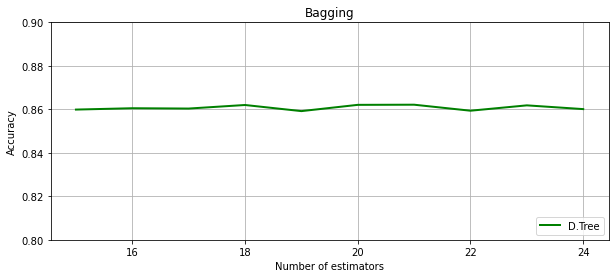

In [43]:
n_est_dict = {}
for n_est in range(15,25): 
    pipeline_bin[1].set_params(n_estimators=n_est)
    bagging_cv = cross_validate(pipeline_bin, X_train, y_train, n_jobs=-1,
                            cv=RepeatedKFold(n_splits=2, n_repeats=3)) 
    n_est_dict[n_est]=bagging_cv['test_score'].mean()

fig = plt.figure(figsize=(10,4))

ne_bag, dtree_bag_scores = n_est_dict.keys(), n_est_dict.values()
plt.plot(ne_bag, dtree_bag_scores, lw=2, color='g', label='D.Tree')

plt.xlabel("Number of estimators")
plt.ylabel("Accuracy")
plt.ylim([0.8,0.9])
plt.legend(loc = 'lower right')
plt.grid()
plt.title('Bagging')
fig.savefig('bag-est-plot.pdf')
pipeline_bin[1].set_params(n_estimators=23)

<font color='CornflowerBlue' size=3>Також можемо глянути на інші метрики класифікатора і на `roc-криву`</font>

In [551]:
output(pipeline_bin, best_base_params=False, all_metrics = True, cv=False)

----------BaggingClassifier(estimator=DecisionTreeClassifier(criterion='log_loss',
                                                   max_depth=12,
                                                   min_samples_leaf=20,
                                                   random_state=4),
                  max_features=0.8, max_samples=0.4, n_estimators=22, n_jobs=-1,
                  random_state=5)----------
Test Accuracy: 0.8657
Train Accuracy: 0.8869

Test Precision: 0.8812
Train Precision: 0.9014

Test Recall: 0.8442
Train Recall: 0.867

Test F1: 0.8623
Train F1: 0.8839

Test ROC_AUC: 0.8656
Train ROC_AUC: 0.8868


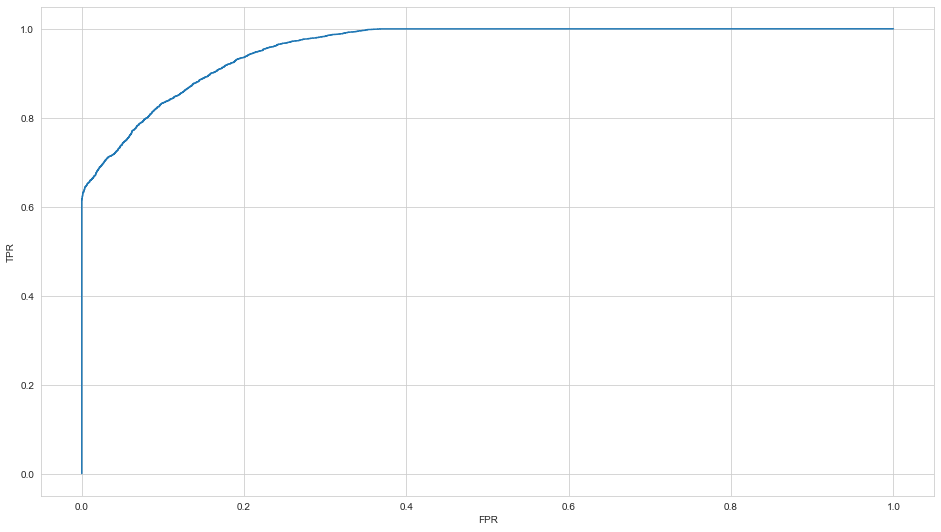

0.9587202312616605

In [555]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
fig, ax = plt.subplots(figsize=(16,9))
fpr, tpr, thresholds = roc_curve(y_test, pipeline_bin.predict_proba(X_test)[:, 1])
ax.plot(fpr, tpr)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
plt.show()
auc(fpr, tpr)
get_original()

Бачимо, що всі метрики приблизно на одному рівні, `roc-крива`, хоч і не ідеальна, але доволі близька до точки (0,1)

<font color='CornflowerBlue' size=3>Висновок</font>

Найкращою моделлю `BaggingClassifier` була модель з скейлингом, бінаризацією, підбором найкращих параметрів для дерева і ансамблю в цілому і з видаленими `outliers`

### GradientBoostClassifier

<font color='CornflowerBlue' size=3>Спробуємо спочатку чисту модель</font>

In [44]:
from sklearn.ensemble import GradientBoostingClassifier
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', GradientBoostingClassifier())
]) 
output(pipeline, best_base_params=False) 

----------GradientBoostingClassifier()----------
Test Accuracy: 0.8094
Train Accuracy: 0.8355
CV mean Result: 0.8086


Бачимо, що результати зразу одні з найкращих. Додамо скейлинг і поексперементуємо з бінаризацією.

In [45]:
column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), features),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), features)
])
pipeline_bin1 = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', GradientBoostingClassifier())
]) 
output(pipeline_bin1, best_base_params=False)

----------GradientBoostingClassifier()----------
Test Accuracy: 0.8666
Train Accuracy: 0.8838
CV mean Result: 0.8632


Бачимо, що бінаризація значно покращила результат

<font color='CornflowerBlue' size=3>Підберемо параметри для бустера</font>

In [46]:
output(pipeline_bin1, best_base_params=False,best_params=True, cv=False)

----------GradientBoostingClassifier(learning_rate=0.19573417814876617, max_depth=5,
                           max_features='sqrt', min_samples_leaf=10,
                           n_estimators=120)----------
Test Accuracy: 0.9064
Train Accuracy: 0.9718


In [47]:
eval_cv([pipeline_bin1],False)

CV mean Result: 0.8996


Бачимо, що результати покращились.

<font color='CornflowerBlue' size=3>Спробуємо викинути об'єкти, які вважаємо `outliers`</font>

In [48]:
delete = outliers(data_train, features, 20)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=4)
output(pipeline_bin1, best_params=True,best_base_params=False, cv=False)

----------GradientBoostingClassifier(learning_rate=0.19573417814876617, max_depth=5,
                           max_features='sqrt', min_samples_leaf=10,
                           n_estimators=120)----------
Test Accuracy: 0.9239
Train Accuracy: 0.9902


In [49]:
eval_cv([pipeline_bin1],False)

CV mean Result: 0.9129


Бачимо, що результати на тестовій вибірці значно вищі, але при крос-валідації різниця не така велика

Спробуємо задати `GradientBoost` з оптимальними параметрами, як модель для початкових передбачень в `init`.

In [50]:
pipeline_bin2 = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', GradientBoostingClassifier(init=pipeline_bin1[1]))
]) 
output(pipeline_bin2, best_base_params=False, best_params=True)

----------GradientBoostingClassifier(init=GradientBoostingClassifier(learning_rate=0.19573417814876617,
                                                           max_depth=5,
                                                           max_features='sqrt',
                                                           min_samples_leaf=10,
                                                           n_estimators=120),
                           learning_rate=0.19573417814876617, max_depth=5,
                           max_features='sqrt', min_samples_leaf=10,
                           n_estimators=120)----------
Test Accuracy: 0.9345
Train Accuracy: 0.9999
CV mean Result: 0.9219


Результати покращились.

<font color='CornflowerBlue' size=3>Також можемо глянути на інші метрики класифікатора і на `roc-криву`</font>

In [558]:
output(pipeline_bin2, best_base_params=False, all_metrics=True, cv=False)

----------GradientBoostingClassifier(init=GradientBoostingClassifier(learning_rate=0.19573417814876617,
                                                           max_depth=5,
                                                           max_features='sqrt',
                                                           min_samples_leaf=10,
                                                           n_estimators=120),
                           learning_rate=0.19573417814876617, max_depth=5,
                           max_features='sqrt', min_samples_leaf=10,
                           n_estimators=120)----------
Test Accuracy: 0.9324
Train Accuracy: 0.9997

Test Precision: 0.9326
Train Precision: 0.9998

Test Recall: 0.9317
Train Recall: 0.9997

Test F1: 0.9321
Train F1: 0.9997

Test ROC_AUC: 0.9324
Train ROC_AUC: 0.9997


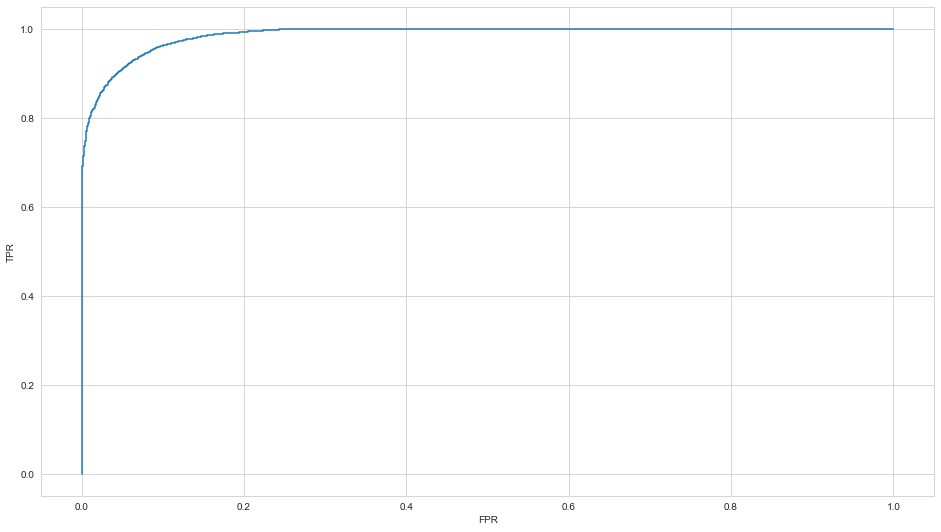

0.9870735097090229

In [561]:
fig, ax = plt.subplots(figsize=(16,9))
fpr, tpr, thresholds = roc_curve(y_test, pipeline_bin2.predict_proba(X_test)[:, 1])
ax.plot(fpr, tpr)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
plt.show()
auc(fpr, tpr)
get_original()

Знову ж таки бачимо, що всі метрики на одному рівні, але в порівнянні з `BaggingClassifier` вони значно вищі, як і площа під `roc-кривою`

<font color='CornflowerBlue' size=3>Спробуємо тепер ознаки з `Feature Selection`</font>

In [51]:
get_original()
res = {}
feats = {"features": features, "low_corr": low_corr, "lin_selected": lin_selected, "tree_selected":tree_selected, "combined": combined}
for name, feat in feats.items():
    output(pipeline_feat, best_base_params=False, best_params=True, cv=False)
    bagging_cv = cross_validate(pipeline_feat, X_train, y_train, n_jobs=-1,
                    cv=RepeatedKFold(n_splits=3, n_repeats=3), scoring="accuracy")
    res[name] =  [round(bagging_cv['test_score'].mean(),4)]
delete = outliers(data_train, features, 20)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=4)
for name, feat in feats.items():
    column_transformer_feat = ColumnTransformer([
    ("scaler", StandardScaler(), feat),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), feat)
    ])
    pipeline_feat = Pipeline(steps=[
        ('preprocessing', column_transformer_feat),
        ('regression', GradientBoostingClassifier())
    ]) 
    output(pipeline_feat, best_base_params=False, best_params=True, cv=False)
    bagging_cv = cross_validate(pipeline_feat, X_train, y_train, n_jobs=-1,
                    cv=RepeatedKFold(n_splits=3, n_repeats=3), scoring="accuracy")
    res[name].append(round(bagging_cv['test_score'].mean(),4))


----------GradientBoostingClassifier(learning_rate=0.19573417814876617, max_depth=5,
                           max_features='sqrt', min_samples_leaf=10,
                           n_estimators=120)----------
Test Accuracy: 0.9053
Train Accuracy: 0.9723
----------GradientBoostingClassifier(criterion='squared_error',
                           learning_rate=0.825404185268019, max_depth=9,
                           n_estimators=170)----------
Test Accuracy: 0.8759
Train Accuracy: 1.0
----------GradientBoostingClassifier(learning_rate=0.01778279410038923,
                           loss='exponential', max_features='log2',
                           min_samples_leaf=4, n_estimators=160, subsample=0.4)----------
Test Accuracy: 0.7526
Train Accuracy: 0.7513
----------GradientBoostingClassifier(learning_rate=0.01778279410038923,
                           loss='exponential', max_features='log2',
                           min_samples_leaf=4, n_estimators=160, subsample=0.4)----------
Test Ac

In [52]:
res["Index"] = ["Outliers", "no Outliers"]
pd.DataFrame(res).set_index("Index")

,features,low_corr,lin_selected,tree_selected,combined
Index,,,,,
Outliers,0.8973,0.8693,0.7513,0.7513,0.7514
no Outliers,0.9110,0.8705,0.8166,0.8132,0.8156


Бачимо, що результати не втішні, але не слід забувати, що швидкість навчання значно зросла

<font color='CornflowerBlue' size=3>Висновок</font>

Найкращою моделлю `GradientBoostingClassifier` була модель з скейлингом, бінаризацією, підбором найкращих параметрів і з видаленими `outliers`.

### Predictions

In [585]:
delete = outliers(data_train, features, 20)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=4)
output(pipeline_bin2,best_base_params=False, cv=True)

----------GradientBoostingClassifier(init=GradientBoostingClassifier(learning_rate=0.19573417814876617,
                                                           max_depth=5,
                                                           max_features='sqrt',
                                                           min_samples_leaf=10,
                                                           n_estimators=120),
                           learning_rate=0.19573417814876617, max_depth=5,
                           max_features='sqrt', min_samples_leaf=10,
                           n_estimators=120)----------
Test Accuracy: 0.931
Train Accuracy: 1.0
CV mean Result: 0.9219


In [586]:
predict = pd.read_csv("data300_test.csv")

In [587]:
# Зберегти прогнози у змінну best_ens_predictions
pipeline_bin2.fit(X_train, y_train)
best_ens_predictions = pipeline_bin2.predict(predict)

In [588]:
# Запустити для створення файлу
pd.Series(best_ens_predictions).to_csv('predictions_ens.csv')


### Clustering

In [5]:
get_original()
X

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_291,x_292,x_293,x_294,x_295,x_296,x_297,x_298,x_299,x_300
0,-0.85,0.12,-0.08,1.17,-0.79,0.56,0.11,-0.06,-0.10,-2.01,...,-1.12,0.38,-0.02,1.31,-0.04,2.35,-0.02,1.20,0.18,-0.00
1,-0.13,0.22,-0.00,-0.07,0.17,0.78,1.12,0.39,-0.00,-1.17,...,-0.34,0.36,-0.03,1.55,-0.00,-2.96,-0.03,0.98,1.36,-0.02
2,-0.17,0.58,0.01,-0.62,1.13,-0.63,-0.59,0.11,0.02,-0.93,...,-1.55,0.77,0.00,-0.68,0.00,-0.28,0.00,-0.05,0.72,0.01
3,0.10,0.84,0.04,-1.20,-0.52,1.97,-0.65,-0.33,0.06,0.22,...,-0.45,0.52,0.00,0.35,0.00,-0.69,0.14,-0.18,-0.99,0.04
4,-0.87,0.30,0.02,-1.15,0.08,0.62,-0.03,0.87,0.04,0.29,...,-0.62,1.49,0.02,0.24,0.00,0.69,0.00,-1.02,-1.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-0.97,-0.56,-0.00,-0.44,-0.77,-0.31,1.69,-1.66,-0.00,-1.80,...,0.99,0.43,-0.03,-0.01,-0.01,1.12,-0.04,0.38,-0.24,-0.03
39996,0.53,0.09,0.01,-0.65,0.90,-0.32,0.12,2.19,0.00,-0.30,...,-0.04,-1.86,0.02,-0.22,0.02,-0.30,0.02,-1.13,-0.88,0.04
39997,1.70,0.05,0.00,2.03,-1.16,-0.77,0.32,-0.00,0.12,-2.68,...,0.90,0.86,0.02,0.05,0.02,-0.35,0.00,-0.09,-0.10,0.04
39998,0.99,0.34,0.08,0.25,1.05,-1.70,-0.48,-1.86,0.02,-0.49,...,0.54,0.39,0.06,1.00,0.02,-1.16,0.06,0.86,-1.14,0.08


### K-Means

<font color='CornflowerBlue' size=3>Напишемо функцію для виводу результатів кластеризації (порівняння з реальними класами)</font>

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import rand_score
def results(cl_model):
    global X, y
    y_pred = cl_model.fit_predict(X) 
    print("-"*10 + f"{cl_model}" + "-"*10)
    print(f"Rand Score: {round(rand_score(y, y_pred), 4)}")
    print(f"Adjusted Rand Score: {round(adjusted_rand_score(y, y_pred), 4)}")
    print(f"Silhouette Score: {round(silhouette_score(X, y_pred), 4)}")
    print(f"Inertia: {round(-cl_model.score(X))}")
    

Спробуємо зробити кластеризацію на 2 кластери.

In [10]:
kmeans = KMeans(n_clusters=2, random_state=4)
results(kmeans)

----------KMeans(n_clusters=2, random_state=4)----------
Rand Score: 0.5001
Adjusted Rand Score: 0.0002
Silhouette Score: 0.0036
Inertia: 7972636


Бачимо, що кластери не кращі, ніж випадкова модель

Спробуємо додати скейлинг

In [16]:
column_transformer = ColumnTransformer([
    ("Scaler", StandardScaler(), features),
])
pipeline_cl = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', kmeans)
]) 
results(pipeline_cl)

----------Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('Scaler', StandardScaler(),
                                                  Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_291', 'x_292', 'x_293', 'x_294', 'x_295', 'x_296', 'x_297', 'x_298',
       'x_299', 'x_300'],
      dtype='object', length=300))])),
                ('regression', KMeans(n_clusters=2, random_state=4))])----------
Rand Score: 0.6268
Adjusted Rand Score: 0.2536
Silhouette Score: 0.0001
Inertia: 11018716


Бачимо, що хоч `inertia` і збільшилась, але результати за `rand_score` покращились.

<font color='CornflowerBlue' size=3>Спробуємо вручну підібрати параметри`</font>

In [72]:
pipeline_cl[1].set_params(init="random", n_init=50, max_iter = 500, algorithm = "elkan")
results(pipeline_cl)

----------Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('Scaler', StandardScaler(),
                                                  Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_291', 'x_292', 'x_293', 'x_294', 'x_295', 'x_296', 'x_297', 'x_298',
       'x_299', 'x_300'],
      dtype='object', length=300))])),
                ('regression',
                 KMeans(algorithm='elkan', init='random', max_iter=500,
                        n_clusters=2, n_init=50, random_state=4))])----------
Rand Score: 0.6268
Adjusted Rand Score: 0.2536


Бачимо, що результат не покращується на жодних параметрах.

<font color='CornflowerBlue' size=3>Подивимось на розподіл змінної `Category` всередині кожного кластеру</font>

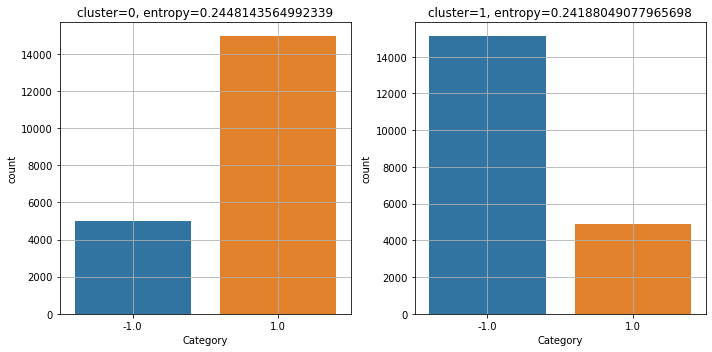

In [77]:
preds = pipeline_cl.fit_predict(X)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

for c_lbl in range(2):
    idxs = preds == c_lbl
    entropy = 0
    for c in [-1,1]:
        p = np.mean(y[idxs] == c)
        entropy += -p*np.log10(p)
    sns.countplot(y[idxs], ax = ax[c_lbl])
    ax[c_lbl].set_title(f'cluster={c_lbl}, entropy={entropy}')
    ax[c_lbl].grid()
    
plt.tight_layout()
plt.show()

In [78]:
preds_bin = np.array(list(map(lambda x: 1 if x == 0 else -1,preds)))

In [79]:
round(accuracy_score(y, preds_bin), 4)

0.7518

Тобто, фактично, якщо знати відповідність кластерів і класів, то точність кластеризації буде 0.75

### DBSCAN

<font color='CornflowerBlue' size=3>Спробуємо базові параметри DBSCAN</font>

In [17]:
from sklearn.cluster import DBSCAN
db = DBSCAN()
db.fit(X)
db.labels_

array([-1, -1, -1, ..., -1, -1, -1], dtype=int64)

In [18]:
all(db.labels_ == -1)

True

Бачимо, що всі значення -1, що значить неможливість виділити щільні класи з такими параметрами

Спробуємо додати скейлинг

In [19]:
pipeline_db = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', db)
])
res = pipeline_db.fit_predict(X)
pd.Series(res).value_counts()

-1    40000
dtype: int64

Бачимо, що всеодно потрібно міняти базові параметри для `DBSCAN` для коректної кластеризації

Змінимо параеметри. Для цього спочатку зрозуміємо, яка відстань між нашими точками

In [22]:
a = 100
scaled = StandardScaler().fit_transform(X)
for i in range(40000):
    if i != 0:
        a1 = euclidean(scaled[i], scaled[0])
        if a1 < a:
            a = a1

In [23]:
a

20.438414915451176

Тобто найближча точка до першої на відстані 20. Поставимо нові параметри

In [24]:
pipeline_db[1].set_params(eps=17.6, min_samples = 30)
res = pipeline_db.fit_predict(X)
pd.Series(res).value_counts()

-1    38558
 1      885
 0      513
 3       23
 2       21
dtype: int64

In [25]:
pipeline_db[1].set_params(eps=19, min_samples = 30)
res = pipeline_db.fit_predict(X)
pd.Series(res).value_counts()

-1    20200
 0    19800
dtype: int64

Поексперементувавши з параметрами можна сказати, що домогтися декількох коректних класів з великою кількістю елементів не виходить. Є підозра, що основна частина даних щільна, а решту є 'викидами'

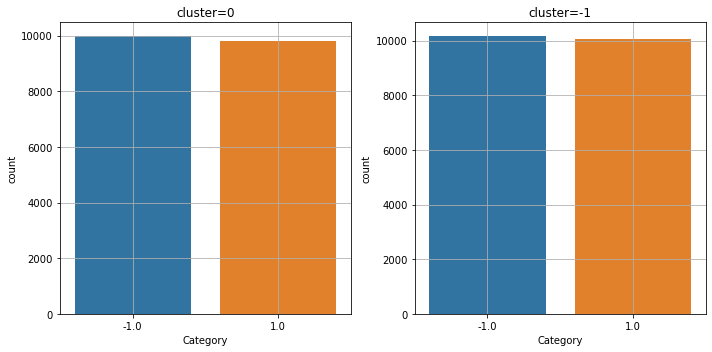

In [26]:
preds = res
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
for c_lbl in [-1, 0]:
    idxs = preds == c_lbl
    sns.countplot(y[idxs], ax = ax[c_lbl])
    ax[c_lbl].set_title(f'cluster={c_lbl}')
    ax[c_lbl].grid()
    
plt.tight_layout()
plt.show()

In [29]:
results(pipeline_db)

----------Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('Scaler', StandardScaler(),
                                                  Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_291', 'x_292', 'x_293', 'x_294', 'x_295', 'x_296', 'x_297', 'x_298',
       'x_299', 'x_300'],
      dtype='object', length=300))])),
                ('regression', DBSCAN(eps=19, min_samples=30))])----------
Rand Score: 0.5
Adjusted Rand Score: -0.0


Але як бачимо, це не розділяє наші дані на 2 потрібні класи

### Завдання 3. 

[12 балів] + [прогнози: до 6 балів]

Для датасету `data_train.csv`
(121 ознака : числові та текстові, цільова змінна TARGET приймає 2 значення -- класи дуже незбалансовані)

Отримати найкращий класифікатор використовуючи не дуже глибокі нейронні мережі. Зберегти прогнози найкращої моделі на датасеті `data_test.csv` до файлу `predictions_ann.csv`.



In [327]:
data_train2 = pd.read_csv("data_train.csv")
data_train2

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,247330,0,Cash loans,F,N,N,0,157500.0,706410.0,67072.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,425716,1,Cash loans,F,Y,Y,1,121500.0,545040.0,25407.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,331625,0,Cash loans,M,Y,Y,1,225000.0,942300.0,27679.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
3,455397,0,Revolving loans,F,N,Y,2,144000.0,180000.0,9000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,2.0
4,449114,0,Cash loans,F,N,Y,0,112500.0,729792.0,37390.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,228498,0,Cash loans,M,N,N,0,94500.0,225000.0,16821.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
149996,413445,0,Cash loans,M,N,N,2,67500.0,269550.0,13761.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
149997,449099,0,Revolving loans,F,N,Y,0,90000.0,247500.0,12375.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
149998,438150,0,Cash loans,M,N,Y,0,225000.0,584766.0,28260.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0


### Data Analysis

In [31]:
data_train2.shape

(150000, 122)

In [32]:
data_train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 139.6+ MB


Отже, маємо `150 000` об'єктів, `121` ознаку (`105` числових і `16` категорійних) і цільову змінну

Подивимось на опис кожної ознаки

In [211]:
import ipywidgets as widgets
def get_describe(column):
    return data_train2[column].describe()
widgets.interact(get_describe, column=widgets.Dropdown(options=data_train2.columns, description="Column:"))

interactive(children=(Dropdown(description='Column:', options=('SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', '…

<function __main__.get_describe(column)>

In [328]:
null = data_train2.isnull().sum()
null[null != 0]

AMT_ANNUITY                       6
AMT_GOODS_PRICE                 131
NAME_TYPE_SUITE                 607
OWN_CAR_AGE                   98932
OCCUPATION_TYPE               47049
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     20280
AMT_REQ_CREDIT_BUREAU_WEEK    20280
AMT_REQ_CREDIT_BUREAU_MON     20280
AMT_REQ_CREDIT_BUREAU_QRT     20280
AMT_REQ_CREDIT_BUREAU_YEAR    20280
Length: 67, dtype: int64

In [329]:
round(null[null != 0].sum()/(150000 * 122), 4)

0.244

Тобто загалом маємо аж `24%` порожніх клітинок

### Null Handling

Подивимось на колонки, відсоток пропущених значень в яких > 50

In [331]:
perc = round((null / 150000) * 100, 2)

In [332]:
perc[perc > 50], len(perc[perc > 50])

(OWN_CAR_AGE                 65.95
 EXT_SOURCE_1                56.36
 APARTMENTS_AVG              50.78
 BASEMENTAREA_AVG            58.55
 YEARS_BUILD_AVG             66.58
 COMMONAREA_AVG              69.92
 ELEVATORS_AVG               53.28
 ENTRANCES_AVG               50.33
 FLOORSMIN_AVG               67.89
 LANDAREA_AVG                59.41
 LIVINGAPARTMENTS_AVG        68.37
 LIVINGAREA_AVG              50.20
 NONLIVINGAPARTMENTS_AVG     69.45
 NONLIVINGAREA_AVG           55.22
 APARTMENTS_MODE             50.78
 BASEMENTAREA_MODE           58.55
 YEARS_BUILD_MODE            66.58
 COMMONAREA_MODE             69.92
 ELEVATORS_MODE              53.28
 ENTRANCES_MODE              50.33
 FLOORSMIN_MODE              67.89
 LANDAREA_MODE               59.41
 LIVINGAPARTMENTS_MODE       68.37
 LIVINGAREA_MODE             50.20
 NONLIVINGAPARTMENTS_MODE    69.45
 NONLIVINGAREA_MODE          55.22
 APARTMENTS_MEDI             50.78
 BASEMENTAREA_MEDI           58.55
 YEARS_BUILD_MEDI   

Цю 41 колонку ми видалимо

In [333]:
data_train2.drop(columns = perc[perc > 50].index, inplace=True)

In [334]:
categorical = data_train2.dtypes[data_train2.dtypes == "object"].index
numeric = data_train2.drop(columns=["TARGET"]).select_dtypes([np.number]).columns


null = data_train2.isnull().sum()
null_cat = np.intersect1d(null[null != 0].index,categorical)
null_num = np.intersect1d(null[null != 0].index,numeric)

<AxesSubplot:xlabel='AMT_ANNUITY'>

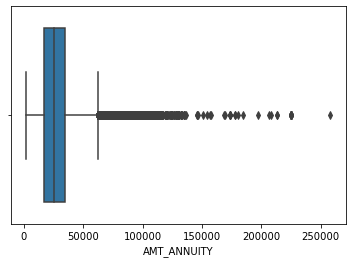

In [335]:
sns.boxplot(data_train2[null[null != 0].index[0]])

В колонках з категорійними змінними пропущенні значення замінимо на моду по відповідному класу. В числових ознаках замінимо на медіану відповідного класу, адже ознаки мають багато викидів, які вплинуть на середнє значення

In [208]:
"""for col in null_cat:
    mode1 = data_train2[data_train2["TARGET"] == 1][col].mode()[0]
    mode0 = data_train2[data_train2["TARGET"] == 0][col].mode()[0]
    data_train2[col] = data_train2.apply(lambda row: mode1 if (pd.isna(row[col]) and row["TARGET"] == 1) else mode0 if (pd.isna(row[col]) and row["TARGET"] == 0) else row[col], axis=1)
for col in null_num:
    med1 = data_train2[data_train2["TARGET"] == 1][col].median()
    med0 = data_train2[data_train2["TARGET"] == 0][col].median()
    data_train2[col] = data_train2.apply(lambda row: med1 if (pd.isna(row[col]) and row["TARGET"] == 1) else med0 if (pd.isna(row[col]) and row["TARGET"] == 0) else row[col], axis=1)"""

In [337]:
for col in null_cat:
    mode = data_train2[col].mode()[0]
    data_train2[col] = data_train2[col].map(lambda x: mode if pd.isna(x) else x)
for col in null_num:
    med = data_train2[col].median()
    data_train2[col] = data_train2[col].map(lambda x: med if pd.isna(x) else x)

In [339]:
categorical = data_train2.dtypes[data_train2.dtypes == "object"].index
numeric = data_train2.drop(columns=["TARGET"]).select_dtypes([np.number]).columns
null = data_train2.isnull().sum()
null[null != 0]

Series([], dtype: int64)

Всі пропущені значення були замінені або видалені

#### Target

<AxesSubplot:xlabel='TARGET', ylabel='count'>

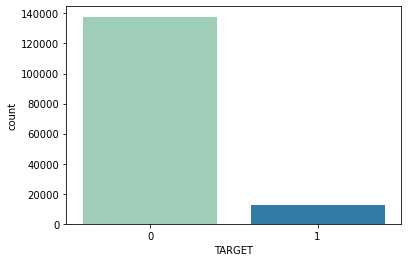

In [340]:
sns.countplot(x='TARGET',data=data_train2, palette="YlGnBu")

In [341]:
data_train2.groupby("TARGET").apply(lambda df: str(round(df["TARGET"].count()/data_train2["TARGET"].count() * 100, 2)) + "%")

TARGET
0    91.88%
1     8.12%
dtype: object

Бачимо високу незбалансованість класів, тому будемо використовувати `stratify` при навчанні. Також розуміємо, що всі класифікатори, які показуватимуть результат нижче 0.9188 є неефективними

#### Correlations

In [342]:
corr2 = data_train2[numeric].corr()
print(f"Min correlation: {corr2.min().min()}")
print(f"Max correlation: {corr2[corr2<1].max().max()}")

Min correlation: -0.9997524193224807
Max correlation: 0.9983691086269929


In [343]:
corr2[(corr2<1) & (corr2 > 0.7)].count().sum() // 2

15

Тобто маємо 15(126, якби ми не викинули колонки) пар ознак, кореляція між якими більша `0.7`

#### Outliers Handling

In [346]:
len(outliers(data_train2, numeric,10))

14756

Викидів доволі багато, але всеодно спробуємо їх прибирати

### Classification

Поділимо дані на навчальні і тестові, використовуючи `stratify`

In [565]:
def get_original2():
    global X, y, X_train, X_test, y_train, y_test
    X = data_train2.drop(columns=["TARGET"])
    y = data_train2["TARGET"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=4, stratify = y)
get_original2()

<font color='CornflowerBlue' size=3>Спробуємо нейронну мережу глибини 3, навчену на числових ознаках</font>

In [348]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import keras
model = Sequential()
model.add(Dense(8, input_dim=len(X[numeric].columns), activation="relu"))
model.add(Dense(4, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [349]:
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 8)                 544       
                                                                 
 dense_22 (Dense)            (None, 4)                 36        
                                                                 
 dense_23 (Dense)            (None, 1)                 5         
                                                                 
Total params: 585 (2.29 KB)
Trainable params: 585 (2.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [350]:
model.compile(loss = "binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train[numeric], y_train, epochs = 10, verbose = 1, validation_split = 0.2)

Epoch 1/10
2250/2250 [==============================] - 3s 1ms/step - loss: 100.3393 - accuracy: 0.8658 - val_loss: 0.5619 - val_accuracy: 0.9174
Epoch 2/10
2250/2250 [==============================] - 2s 961us/step - loss: 1.6742 - accuracy: 0.9191 - val_loss: 0.3410 - val_accuracy: 0.9174
Epoch 3/10
2250/2250 [==============================] - 2s 964us/step - loss: 0.7455 - accuracy: 0.9191 - val_loss: 0.3189 - val_accuracy: 0.9174
Epoch 4/10
2250/2250 [==============================] - 2s 964us/step - loss: 0.5348 - accuracy: 0.9191 - val_loss: 0.2959 - val_accuracy: 0.9174
Epoch 5/10
2250/2250 [==============================] - 2s 962us/step - loss: 0.3896 - accuracy: 0.9191 - val_loss: 0.2850 - val_accuracy: 0.9174
Epoch 6/10
2250/2250 [==============================] - 2s 960us/step - loss: 0.3345 - accuracy: 0.9191 - val_loss: 0.2853 - val_accuracy: 0.9174
Epoch 7/10
2250/2250 [==============================] - 2s 961us/step - loss: 0.2946 - accuracy: 0.9191 - val_loss: 0.2850 -

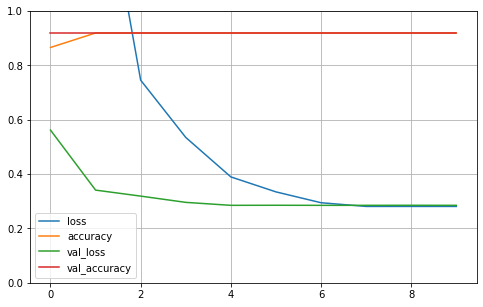

In [351]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

Бачимо, що з кожним кроком accuracy майже не змінюється. Подивимось на результати на вибірках.

In [352]:
def show(model, all_metrics=False, overs=False):
    global y_train_pred, y_pred, resampled_labels
    print("-"*10 + f"{model}" + "-"*10)
    print(f"Test Accuracy: {round(accuracy_score(y_test, y_pred.round()), 4)}")
    if not overs:
        print(f"Train Accuracy: {round(accuracy_score(y_train, y_train_pred.round()), 4)}")
    else:
        print(f"Train Accuracy: {round(accuracy_score(resampled_labels, y_train_pred.round()), 4)}")
    if all_metrics:
        for metric, scorer in {"Precision":precision_score,"Recall":recall_score,"F1":f1_score, "ROC_AUC":roc_auc_score}.items():
            print()
            print(f"Test {metric}: {round(scorer(y_test, y_pred), 4)}")
            print(f"Train {metric}: {round(scorer(y_train, y_train_pred), 4)}")

            
y_train_pred = model.predict(X_train[numeric])
y_pred = model.predict(X_test[numeric])
show(model)

1875/1875 [==============================] - 1s 656us/step
----------<keras.src.engine.sequential.Sequential object at 0x0000013D6E517E80>----------
Test Accuracy: 0.9188
Train Accuracy: 0.9188


In [353]:
all(y_pred.round() == 0)

True

Як можна зрозуміти, через незбалансовані класи, наша модель видає лише значення 0. Тобто працює неефективно

<font color='CornflowerBlue' size=3>Спробуємо додати скейлинг, зменшити `learning_rate`, додати ваги нашим класам і додати шар `Dropout`</font>

In [392]:
model1 = Sequential()
model1.add(Dense(8, input_dim=len(X[numeric].columns), activation="relu"))
model1.add(Dropout(0.5))
model1.add(Dense(4, activation="relu"))
model1.add(Dense(1, activation="sigmoid"))

In [393]:
column_transformer_nn = ColumnTransformer([
    ("scaler", StandardScaler(), numeric),
])
X_train_scaled = column_transformer_nn.fit_transform(X_train)
X_test_scaled = column_transformer_nn.fit_transform(X_test)

model1.compile(loss = "binary_crossentropy", metrics=["accuracy",keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')], 
              optimizer=keras.optimizers.Adam(learning_rate=1e-3))
model1.fit(X_train_scaled, y_train, epochs = 20, verbose = 1, class_weight = {0: 0.4, 1: 0.6}, validation_split = 0.2)

y_train_pred = model1.predict(X_train_scaled)
y_pred = model1.predict(X_test_scaled)
show(model1)

Epoch 1/20
2250/2250 [==============================] - 3s 1ms/step - loss: 0.1654 - accuracy: 0.8987 - precision: 0.0835 - recall: 0.0252 - val_loss: 0.2740 - val_accuracy: 0.9173 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
2250/2250 [==============================] - 2s 1ms/step - loss: 0.1411 - accuracy: 0.9187 - precision: 0.1111 - recall: 6.8670e-04 - val_loss: 0.2683 - val_accuracy: 0.9173 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
2250/2250 [==============================] - 3s 1ms/step - loss: 0.1397 - accuracy: 0.9188 - precision: 0.0769 - recall: 3.4335e-04 - val_loss: 0.2688 - val_accuracy: 0.9174 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
2250/2250 [==============================] - 2s 1ms/step - loss: 0.1389 - accuracy: 0.9190 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.2675 - val_accuracy: 0.9174 - val_precision: 0.3333 - val_recall: 6.7295e-04
Epoch 5/20
2250/2250 [==============================

Бачимо, що результати не змінились

In [394]:
y_pred

array([[0.04817804],
       [0.04161046],
       [0.1498723 ],
       ...,
       [0.21851413],
       [0.02045247],
       [0.06192422]], dtype=float32)

In [395]:
a = y_pred.round()
all(a == 0)

True

### OverSampling

<font color='CornflowerBlue' size=3>Спробуємо `oversampling`. Продублюємо елементи меншого класу випадковим чином стільки разів, щоб класи стали збалансовані</font>

In [374]:
train_labels = np.array(y_train)
bool_train_labels = train_labels != 0
train_features = np.array(X_train[numeric])

In [375]:
pos_features = train_features[bool_train_labels]
neg_features = train_features[~bool_train_labels]
pos_labels = train_labels[bool_train_labels]
neg_labels = train_labels[~bool_train_labels]

In [376]:
ids = np.arange(len(pos_features))
choices = np.random.choice(ids, len(neg_features))

res_pos_features = pos_features[choices]
res_pos_labels = pos_labels[choices]

res_pos_features.shape

(82689, 67)

In [377]:
resampled_features = np.concatenate([res_pos_features, neg_features], axis=0)
resampled_labels = np.concatenate([res_pos_labels, neg_labels], axis=0)

order = np.arange(len(resampled_labels))
np.random.shuffle(order)
resampled_features = resampled_features[order]
resampled_labels = resampled_labels[order]

resampled_features.shape

(165378, 67)

Text(0.5, 1.0, 'After Resampling')

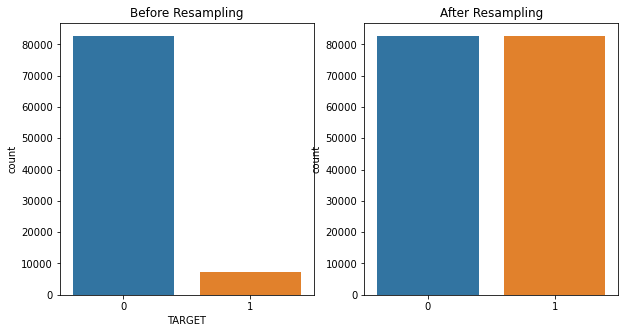

In [378]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.countplot(resampled_labels, ax = ax[1])
sns.countplot(y_train, ax = ax[0])
ax[0].set_title("Before Resampling")
ax[1].set_title("After Resampling")

In [382]:
model2 = Sequential()
model2.add(Dense(8, input_dim=len(X[numeric].columns), activation="relu"))
model2.add(Dense(4, activation="relu"))
model2.add(Dense(1, activation="sigmoid"))
model2.compile(loss = "binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-2), metrics=["accuracy",keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')])
X_train_scaled = StandardScaler().fit_transform(resampled_features)
X_test_scaled = StandardScaler().fit_transform(X_test[numeric])
model2.fit(X_train_scaled, resampled_labels, epochs = 10, verbose = 1)

Epoch 1/10
5169/5169 [==============================] - 5s 923us/step - loss: 0.6118 - accuracy: 0.6700 - precision: 0.6722 - recall: 0.6634
Epoch 2/10
5169/5169 [==============================] - 5s 920us/step - loss: 0.6031 - accuracy: 0.6759 - precision: 0.6776 - recall: 0.6710
Epoch 3/10
5169/5169 [==============================] - 5s 924us/step - loss: 0.6003 - accuracy: 0.6776 - precision: 0.6787 - recall: 0.6746
Epoch 4/10
5169/5169 [==============================] - 5s 942us/step - loss: 0.5989 - accuracy: 0.6790 - precision: 0.6795 - recall: 0.6778
Epoch 5/10
5169/5169 [==============================] - 5s 925us/step - loss: 0.5972 - accuracy: 0.6802 - precision: 0.6782 - recall: 0.6860
Epoch 6/10
5169/5169 [==============================] - 5s 951us/step - loss: 0.5962 - accuracy: 0.6805 - precision: 0.6802 - recall: 0.6813
Epoch 7/10
5169/5169 [==============================] - 5s 926us/step - loss: 0.5954 - accuracy: 0.6784 - precision: 0.6792 - recall: 0.6760
Epoch 8/10
51

In [383]:
y_train_pred = model2.predict(X_train_scaled)
y_pred = model2.predict(X_test_scaled)
show(model2, overs=True)

1875/1875 [==============================] - 1s 664us/step
----------<keras.src.engine.sequential.Sequential object at 0x0000013C95FD2760>----------
Test Accuracy: 0.5442
Train Accuracy: 0.6761


Результати погіршились

<font color='CornflowerBlue' size=3>Спробуємо додати у нашу модель шар `Dropout`, який міняє ваги деяких ознак на 0 (регуляризація)</font>

In [384]:
model3 = Sequential()
model3.add(Dense(8, input_dim=len(X[numeric].columns), activation="relu"))
model3.add(Dropout(0.5))
model3.add(Dense(4, activation="relu"))
model3.add(Dense(1, activation="sigmoid"))
model3.compile(loss = "binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-3), metrics=["accuracy",keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')])
model3.fit(x=X_train_scaled, y=resampled_labels, epochs = 10, verbose = 1)

Epoch 1/10
5169/5169 [==============================] - 6s 958us/step - loss: 0.6394 - accuracy: 0.6356 - precision: 0.6322 - recall: 0.6483
Epoch 2/10
5169/5169 [==============================] - 5s 950us/step - loss: 0.6225 - accuracy: 0.6584 - precision: 0.6485 - recall: 0.6920
Epoch 3/10
5169/5169 [==============================] - 5s 956us/step - loss: 0.6196 - accuracy: 0.6599 - precision: 0.6487 - recall: 0.6974
Epoch 4/10
5169/5169 [==============================] - 5s 967us/step - loss: 0.6185 - accuracy: 0.6618 - precision: 0.6494 - recall: 0.7037
Epoch 5/10
5169/5169 [==============================] - 5s 958us/step - loss: 0.6170 - accuracy: 0.6616 - precision: 0.6501 - recall: 0.6999
Epoch 6/10
5169/5169 [==============================] - 5s 950us/step - loss: 0.6162 - accuracy: 0.6607 - precision: 0.6505 - recall: 0.6947
Epoch 7/10
5169/5169 [==============================] - 5s 956us/step - loss: 0.6156 - accuracy: 0.6631 - precision: 0.6485 - recall: 0.7120
Epoch 8/10
51

In [385]:
y_train_pred = model3.predict(X_train_scaled)
y_pred = model3.predict(X_test_scaled)
show(model3, overs=True)

157/157 [==============================] - 0s 693us/step
----------<keras.src.engine.sequential.Sequential object at 0x0000013C9601ABB0>----------
Test Accuracy: 0.5606
Train Accuracy: 0.6812


Бачимо, що це знову не допомогло

### UnderSampling

<font color='CornflowerBlue' size=3>Виберемо з переважаючого класу випадково таку кількість елементів, щоб класи були збалансовані</font>

In [424]:
ids = np.arange(len(neg_features))
choices = np.random.choice(ids, len(pos_features))

In [425]:
res_neg_features = neg_features[choices]
res_neg_labels = neg_labels[choices]

res_neg_features.shape

(7311, 67)

In [426]:
resampled_features = np.concatenate([res_neg_features, pos_features], axis=0)
resampled_labels = np.concatenate([res_neg_labels, pos_labels], axis=0)

order = np.arange(len(resampled_labels))
np.random.shuffle(order)
resampled_features = resampled_features[order]
resampled_labels = resampled_labels[order]

resampled_features.shape

(14622, 67)

Text(0.5, 1.0, 'After Resampling')

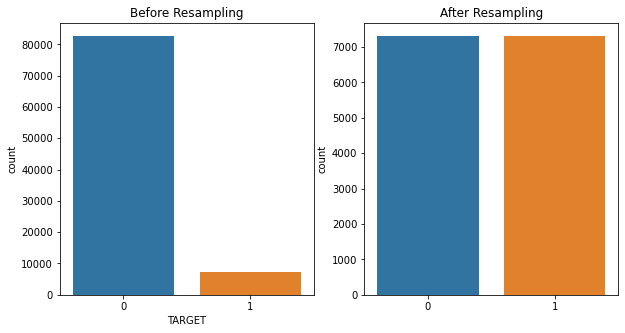

In [427]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.countplot(resampled_labels, ax = ax[1])
sns.countplot(y_train, ax = ax[0])
ax[0].set_title("Before Resampling")
ax[1].set_title("After Resampling")

In [438]:
model4 = Sequential()
model4.add(Dense(128, input_dim=len(X[numeric].columns), activation="relu"))
model4.add(Dropout(0.5))
model4.add(Dense(64, activation="relu"))
model4.add(Dense(32, activation="relu"))
model4.add(Dense(16, activation="relu"))
model4.add(Dense(8, activation="relu"))
model4.add(Dense(4, activation="relu"))
model4.add(Dense(2, activation="relu"))
model4.add(Dense(1, activation="sigmoid"))
model4.compile(loss = "binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-3), metrics=["accuracy",keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')])
X_train_scaled = StandardScaler().fit_transform(resampled_features)
X_test_scaled = StandardScaler().fit_transform(X_test[numeric])
model4.fit(X_train_scaled, resampled_labels, epochs = 30, verbose = 1, validation_split=0.2)

Epoch 1/30
366/366 [==============================] - 2s 2ms/step - loss: 0.6769 - accuracy: 0.5805 - precision: 0.5926 - recall: 0.5052 - val_loss: 0.6560 - val_accuracy: 0.6359 - val_precision: 0.6133 - val_recall: 0.7642
Epoch 2/30
366/366 [==============================] - 1s 2ms/step - loss: 0.6400 - accuracy: 0.6496 - precision: 0.6401 - recall: 0.6775 - val_loss: 0.6258 - val_accuracy: 0.6533 - val_precision: 0.6552 - val_recall: 0.6685
Epoch 3/30
366/366 [==============================] - 1s 2ms/step - loss: 0.6177 - accuracy: 0.6638 - precision: 0.6673 - recall: 0.6484 - val_loss: 0.6210 - val_accuracy: 0.6656 - val_precision: 0.6818 - val_recall: 0.6395
Epoch 4/30
366/366 [==============================] - 1s 2ms/step - loss: 0.6128 - accuracy: 0.6702 - precision: 0.6773 - recall: 0.6454 - val_loss: 0.6207 - val_accuracy: 0.6643 - val_precision: 0.6736 - val_recall: 0.6563
Epoch 5/30
366/366 [==============================] - 1s 2ms/step - loss: 0.6095 - accuracy: 0.6720 - pr

In [439]:
y_train_pred = model4.predict(X_train_scaled)
y_pred = model4.predict(X_test_scaled)
show(model4, overs=True)

1875/1875 [==============================] - 1s 754us/step
----------<keras.src.engine.sequential.Sequential object at 0x0000013D38682490>----------
Test Accuracy: 0.5313
Train Accuracy: 0.7095


Тобто результат знову не покращується

<font color='CornflowerBlue' size=3>На останок спробуємо визначити найбільш потрібні ознаки за допомогою `RandomForestClassifier`, видалити `outliers` і використати `LabelEncoder` i бінаризацію

In [451]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

column_transformer_nn = ColumnTransformer([
    ("scaler", StandardScaler(), numeric),
])
pipeline_nn = Pipeline(steps=[
    ('preprocessing', column_transformer_nn),
    ('regression', RandomForestClassifier(max_depth = 5, random_state = 4))
]) 

pipeline_nn.fit(X, y)
feature_importances = pipeline_nn[1].feature_importances_
indices = (-feature_importances).argsort()[:10]
X_new = X[numeric].iloc[:, indices]
tree_selected = X_new.columns
tree_selected

Index(['EXT_SOURCE_3', 'EXT_SOURCE_2', 'DAYS_BIRTH', 'AMT_GOODS_PRICE',
       'DAYS_EMPLOYED', 'DAYS_LAST_PHONE_CHANGE',
       'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT',
       'DAYS_ID_PUBLISH', 'AMT_CREDIT'],
      dtype='object')

In [495]:
delete = outliers(data_train2, numeric,5)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
for col in categorical:
    X[col] = LabelEncoder().fit_transform(X[col])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=4)

In [496]:
model5 = Sequential()
model5.add(Dense(8, input_dim=len(np.union1d(tree_selected, categorical)), activation="relu"))
model5.add(Dropout(0.5))
model5.add(Dense(4, activation="relu"))
model5.add(Dense(1, activation="sigmoid"))
model5.compile(loss = "binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-3), metrics=["accuracy",keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')])

In [497]:
column_transformer_nn = ColumnTransformer([
    ("scaler", StandardScaler(), tree_selected),
])
X_train[tree_selected] = column_transformer_nn.fit_transform(X_train)
X_test[tree_selected] =column_transformer_nn.fit_transform(X_test)
model5.fit(X_train[np.union1d(tree_selected, categorical)], y_train, epochs = 10, verbose = 1, validation_split = 0.2)

Epoch 1/10
2813/2813 [==============================] - 3s 944us/step - loss: 0.3041 - accuracy: 0.9179 - precision: 0.0642 - recall: 9.5996e-04
Epoch 2/10
2813/2813 [==============================] - 3s 947us/step - loss: 0.2772 - accuracy: 0.9190 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 3/10
2813/2813 [==============================] - 3s 946us/step - loss: 0.2742 - accuracy: 0.9190 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 4/10
2813/2813 [==============================] - 3s 946us/step - loss: 0.2715 - accuracy: 0.9190 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 5/10
2813/2813 [==============================] - 3s 988us/step - loss: 0.2701 - accuracy: 0.9190 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 6/10
2813/2813 [==============================] - 3s 1ms/step - loss: 0.2695 - accuracy: 0.9190 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 7/10
2813/2813 [==============================] - 3s 1ms/step - loss: 0.2688 - accuracy: 0.9190 - precisio

In [498]:
y_train_pred = model5.predict(X_train[np.union1d(tree_selected, categorical)])
y_pred = model5.predict(X_test[np.union1d(tree_selected, categorical)])
show(model5)

1875/1875 [==============================] - 1s 656us/step
----------<keras.src.engine.sequential.Sequential object at 0x0000013C891C17C0>----------
Test Accuracy: 0.9184
Train Accuracy: 0.919


In [500]:
all(y_train_pred.round() == 0)

True

Знову всі передбачення 0

### MLP

<font color='CornflowerBlue' size=3>Спробуємо також скористатись `MLP` зі `sklearn`</font>

In [504]:
get_original2()

In [505]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(random_state=4)
column_transformer_mlp = ColumnTransformer([
    ("scaler", StandardScaler(), numeric),
])
pipeline_mlp = Pipeline(steps=[
    ('preprocessing', column_transformer_mlp),
    ('regression', MLPClassifier(random_state=1))
]) 
pipeline_mlp.fit(X_train, y_train)
y_train_pred = pipeline_mlp.predict(X_train)
y_pred = pipeline_mlp.predict(X_test)
show(pipeline_mlp)

----------Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBI...
       'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object'))])),
                ('regression', MLPClassifier(random_state=1))])----------
Test Accuracy: 0.9109
Train Accuracy: 0.9253


Результати всеодно гірші, ніж якщо всі предікти 0

Додамо бінаризацію і `OneHot`

In [511]:
from sklearn.preprocessing import OneHotEncoder
categorical = X.dtypes[X.dtypes == "object"].index

column_transformer_mlp = ColumnTransformer([
    ('ohe', OneHotEncoder(), categorical),
    ("scaler", StandardScaler(), numeric),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), numeric)
])
pipeline_mlp = Pipeline(steps=[
    ('preprocessing', column_transformer_mlp),
    ('regression', MLPClassifier(random_state=4))
]) 
pipeline_mlp.fit(X_train, y_train)
y_train_pred = pipeline_mlp.predict(X_train)
y_pred = pipeline_mlp.predict(X_test)
show(pipeline_mlp)

----------Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
       'EMERGENCYSTATE_MODE...
       'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object'))])),
                ('regression', MLPClassifier(random_state=4))])----------
Test Accuracy: 0.8564
Train Accuracy: 0.9947


Результати ще погіршились. Спробуємо підібрати найкращі параметри для моделі

In [425]:
param_grid = {
            "regression__hidden_layer_sizes": [(100,), (128, 64, 32, 16, 8, 4), (8, 4, 1), (16,8, 4)],
            "regression__activation": ["relu", "tanh", "identity", "logistic"],
            "regression__solver": ["adam", "sgd", "lbfgs"],
            "regression__alpha": np.logspace(-4,0, 25),        
            "regression__learning_rate" : ["constant", "adaptive", "invscaling"],
            "regression__max_iter": range(150,500, 50),
            "regression__validation_fraction": np.arange(0.1, 0.5, 0.1)
}
searcher = RandomizedSearchCV(pipeline_mlp, [param_grid],
                scoring="accuracy", cv=3, n_jobs=-1, random_state=4, n_iter=25)
searcher.fit(X_train, y_train)
best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
pipeline_mlp[1].set_params(**best)

MLPClassifier(activation='logistic', alpha=0.0014677992676220691,
              hidden_layer_sizes=(128, 64, 32, 16, 8, 4),
              learning_rate='adaptive', max_iter=450, random_state=4,
              validation_fraction=0.30000000000000004)

In [508]:
pipeline_mlp.fit(X_train, y_train)
y_train_pred = pipeline_mlp.predict(X_train)
y_pred = pipeline_mlp.predict(X_test)
show(pipeline_mlp)

----------Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
       'EMERGENCYSTATE_MODE...
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object'))])),
                ('regression',
                 MLPClassifier(activation='logistic',
                               alpha=0.0014677992676220691,
                               hidden_layer_sizes=(128, 64, 32, 16, 8, 4),
                               learning_rate='adaptive', max_iter=450,
         

In [509]:
all(y_pred == 0)

True

Знову прийшли до нульових передбачень

#### Висновок.
Спробувавши різні підходи до навчання нейронних мереж з різних бібліотек, можемо прийти до висновку, що на даному датасеті, найкраще чого можна досягти таким способом це сталі передбачення (  як би сумно це не було :(   )

In [520]:
modell = Sequential()
modell.add(Dense(16, input_dim=len(X[numeric].columns), activation="relu"))
modell.add(Dense(8, activation="relu"))
modell.add(Dropout(0.5))
modell.add(Dense(4, activation="relu"))
modell.add(Dense(1, activation="sigmoid"))
modell.compile(loss = "binary_crossentropy", metrics=["accuracy",keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')], 
              optimizer=keras.optimizers.Adam(learning_rate=1e-3))
X_train_scaled = StandardScaler().fit_transform(X_train[numeric])
X_test_scaled = StandardScaler().fit_transform(X_test[numeric])
modell.fit(X_train_scaled, y_train, epochs = 20, verbose = 1, validation_split = 0.2)

Epoch 1/20
2250/2250 [==============================] - 3s 1ms/step - loss: 0.3224 - accuracy: 0.9042 - precision: 0.0691 - recall: 0.0148 - val_loss: 0.2653 - val_accuracy: 0.9174 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
2250/2250 [==============================] - 3s 1ms/step - loss: 0.2648 - accuracy: 0.9191 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.2622 - val_accuracy: 0.9174 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
2250/2250 [==============================] - 3s 1ms/step - loss: 0.2616 - accuracy: 0.9190 - precision: 0.1667 - recall: 1.7167e-04 - val_loss: 0.2618 - val_accuracy: 0.9174 - val_precision: 0.5000 - val_recall: 6.7295e-04
Epoch 4/20
2250/2250 [==============================] - 3s 1ms/step - loss: 0.2602 - accuracy: 0.9191 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.2612 - val_accuracy: 0.9174 - val_precision: 0.5000 - val_recall: 6.7295e-04
Epoch 5/20
2250/2250 [==============================

In [521]:
y_train_pred = modell.predict(X_train[numeric])
y_pred = modell.predict(X_test[numeric])
show(modell)

1875/1875 [==============================] - 1s 671us/step
----------<keras.src.engine.sequential.Sequential object at 0x0000013C81D30310>----------
Test Accuracy: 0.9188
Train Accuracy: 0.9188


In [528]:
predict = pd.read_csv("data_test.csv")
for col in null_num:
    med = data_train2[col].median()
    predict[col] = predict[col].map(lambda x: med if pd.isna(x) else x)
pred_scaled = StandardScaler().fit_transform(predict[numeric])

In [537]:
# Зберегти прогнози у змінну best_ann_predictions
best_ann_predictions = modell.predict(pred_scaled).round().reshape(-1)

157/157 [==============================] - 0s 688us/step


In [538]:
# Запустити для створення файлу
pd.Series(best_ann_predictions).to_csv('predictions_ann.csv')

### Зберегти результати роботи у jupyter-ноутбук. Ноутбук повинен бути збережений у стані в якому усі клітинки запущені і не містити помилок. Формат назви файлу `ЕКЗ2_Прізвище_Ім'я.ipynb`. Окремо додати файли `predictions_ens.csv` та `predictions_ann.csv`.


[4 бали]